##DECISION TREE CLASSIFIER##


In [67]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [17]:
#load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

In [26]:
#description of the dataset
print("Dataset Description:")
print(iris.DESCR)

Dataset Description:
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for e

In [27]:
iris['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [33]:
x1 = pd.DataFrame(
    iris.data,
    columns=[
        'sepal length (cm)',
        'sepal width (cm)',
        'petal length (cm)',
        'petal width (cm)'
    ]
)
x1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


<Axes: >

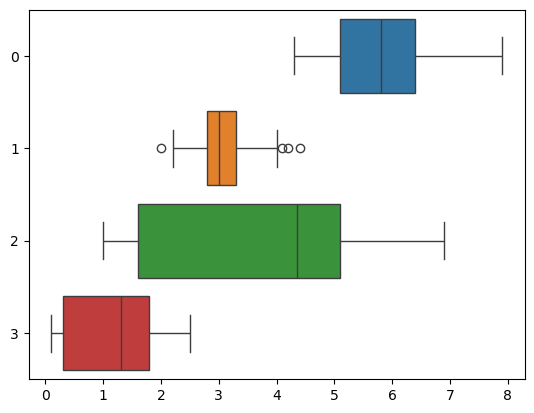

In [18]:
sns.boxplot(data=X, orient="h")

In [19]:
#handle outliers
Q1 = np.percentile(X, 25, axis=0)
Q3 = np.percentile(X, 75, axis=0)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
X = np.where((X < lower_bound) | (X > upper_bound), np.nan, X)
X = np.where(np.isnan(X), np.nanmean(X, axis=0), X)


<Axes: >

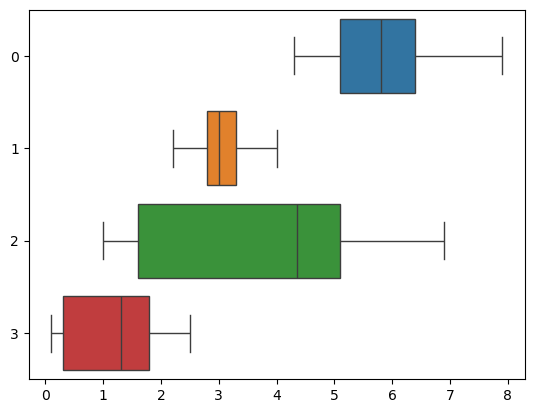

In [20]:
#outlier boxplot after handling outliers
sns.boxplot(data=X, orient="h")

In [21]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
#split the dataset 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [23]:
#train the decision tree classifier
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
#test the model
y_pred = classifier.predict(X_test)


In [35]:
#applying decision tree classifier
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)
#predicting the test set results
y_pred = classifier.predict(X_test)


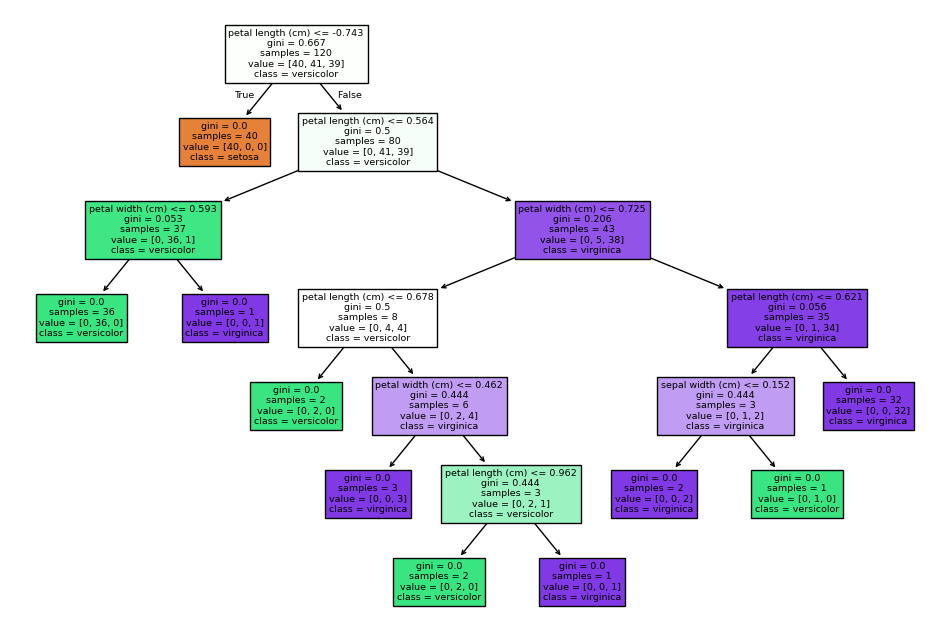

In [36]:
##visualize the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(classifier, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()

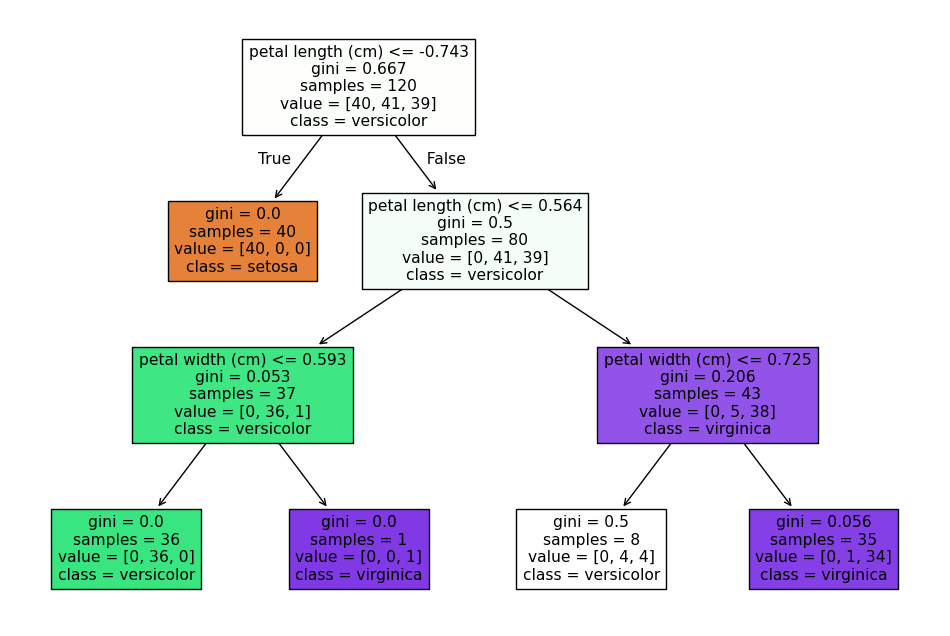

In [38]:
#visualize the pre-pruned decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(pre_pruned_classifier, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()

In [44]:
prams={
    'criterion': ['gini', 'entropy','log_loss'],
    'max_depth': [None, 10, 20, 30,4,6,20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
prams

{'criterion': ['gini', 'entropy', 'log_loss'],
 'max_depth': [None, 10, 20, 30, 4, 6, 20],
 'min_samples_split': [2, 5, 10],
 'min_samples_leaf': [1, 2, 4]}

In [43]:
prams={
    'criterion': ['gini', 'entropy','log_loss'],
    'max_depth': [None, 10, 20, 30,4,6,20],
    'splitter': ['best', 'random'],
    'max_features': [None, 'sqrt', 'log2']
}
prams

{'criterion': ['gini', 'entropy', 'log_loss'],
 'max_depth': [None, 10, 20, 30, 4, 6, 20],
 'splitter': ['best', 'random'],
 'max_features': [None, 'sqrt', 'log2']}

In [60]:
from sklearn.model_selection import GridSearchCV
#tree model
tree_model = DecisionTreeClassifier(random_state=42)
#grid search
grid_search = GridSearchCV(estimator=tree_model, param_grid=prams, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [58]:
grid.best_params_

{'criterion': 'gini', 'max_depth': 3}

In [59]:
grid.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [62]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test, y_pred)
score

1.0

In [64]:
#classification report
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)
#confusion matrix
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
